In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.columns


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [7]:
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
(df['TotalCharges'] == ' ').sum()

np.int64(11)

In [9]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [10]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
df['TotalCharges'] = df['TotalCharges'].fillna(
    df['TotalCharges'].median()
)

In [12]:
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
df.to_csv(
    '../data/cleaned_telco_churn.csv',
    index=False
)

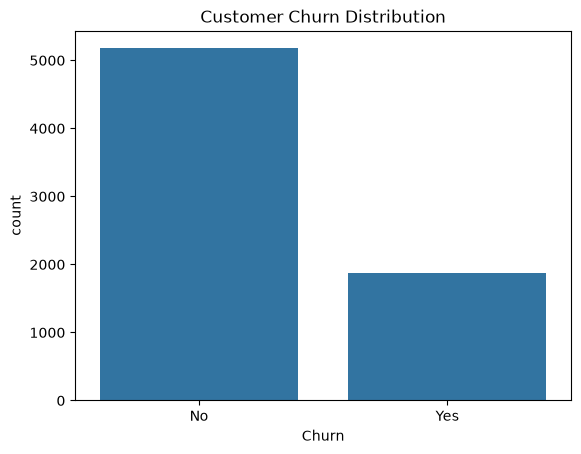

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')
plt.show()

### Observation

The majority of customers remained with the company.

Approximately 74% of customers stayed, while 26% churned.

This indicates that customer churn is a significant business problem and predicting churn can help the company retain customers before they leave.

The dataset is also imbalanced because the number of customers who stayed is much larger than those who churned.

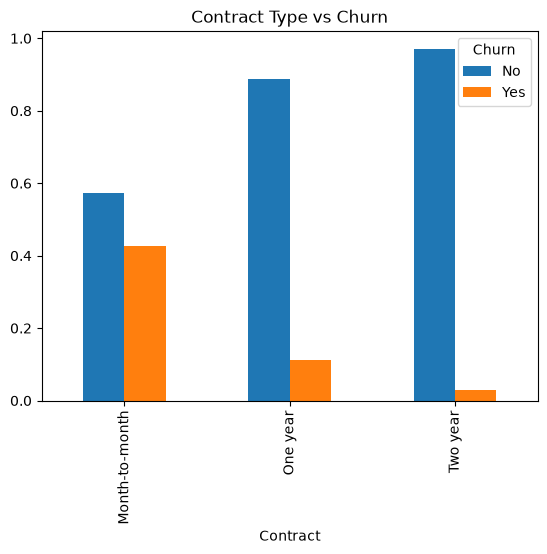

In [15]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
)

contract_churn.plot(kind='bar')

plt.title('Contract Type vs Churn')
plt.show()

### Observation

Contract type has a strong relationship with customer churn.

Customers on month-to-month contracts show the highest churn rate, with nearly 43% leaving the company.

Customers with one-year contracts show significantly lower churn rates, while customers with two-year contracts rarely churn.

### Business Insight

Encouraging customers to switch from month-to-month plans to longer-term contracts may help reduce churn and improve customer retention.

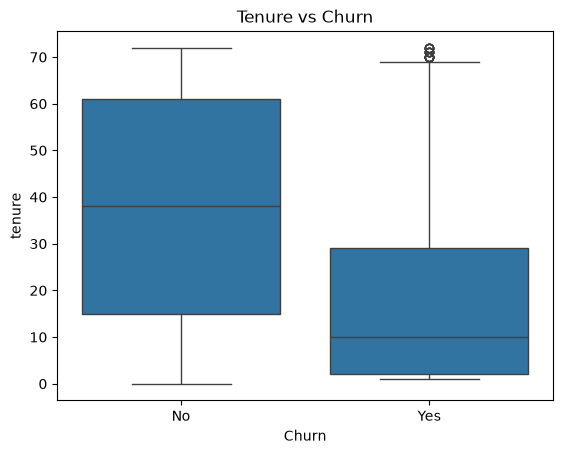

In [16]:
sns.boxplot(
    x='Churn',
    y='tenure',
    data=df
)

plt.title('Tenure vs Churn')
plt.show()

### Observation

Customers who churned generally have much lower tenure compared to customers who stayed.

The median tenure for churned customers is approximately 10 months, while customers who remained have a median tenure of around 38 months.

### Business Insight

Newer customers are significantly more likely to churn than long-term customers. The company should focus on improving customer retention during the first year of service.

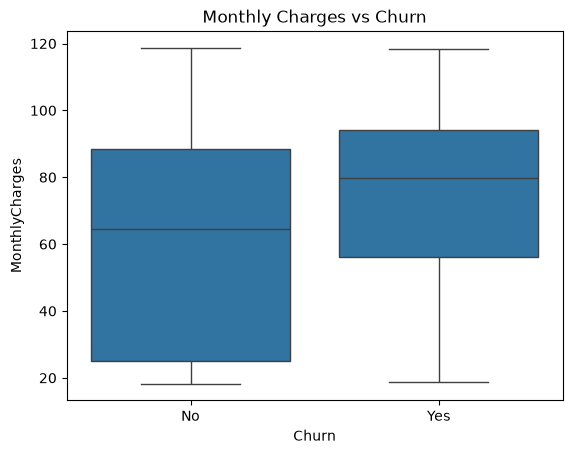

In [17]:
sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title('Monthly Charges vs Churn')
plt.show()

### Observation

Customers who churned tend to have higher monthly charges compared to customers who stayed.

The median monthly charge for churned customers is significantly higher than that of retained customers.

### Business Insight

Customers paying higher monthly fees may be more price-sensitive and therefore more likely to leave the company. Special retention offers or discounts could help reduce churn among these customers.

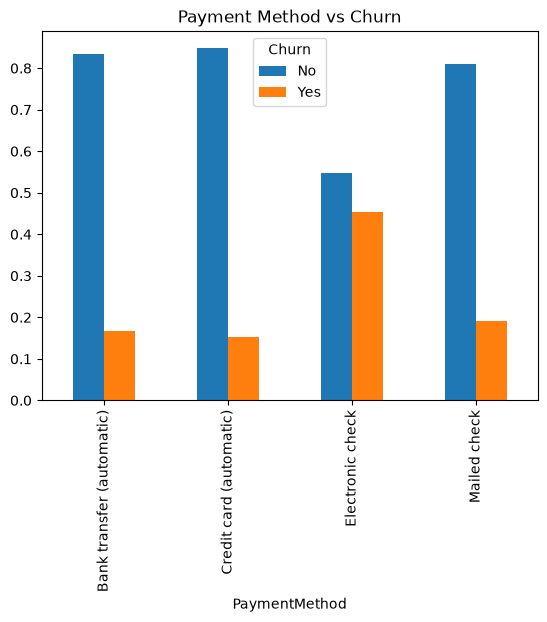

In [18]:
payment = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
)

payment.plot(kind='bar')

plt.title('Payment Method vs Churn')
plt.show()

### Observation

Customers using Electronic Check show the highest churn rate among all payment methods.

Automatic payment methods such as Credit Card (automatic) and Bank Transfer (automatic) have significantly lower churn rates.

### Business Insight

Customers using Electronic Check may require additional retention efforts. Encouraging customers to switch to automatic payment methods may improve customer retention.